# Kleene's Theorem (Part 2)

## Introduction

After completing this chapter, you will be able to:

* Create a regular expression that generates exactly the language recognized by a given NFA.

Again, we'll be creating some directed graphs, so we'll import the libraries for doing so. We'll also use our graph visualization function.

We use these libraries to build and visualize the directed graphs we'll be using in this chapter:

| Package | Purpose |
|---|---|
| `io` | Basic library for handling input and output |
| `base64` | Manages special characters |
| `IPython` | Provides additional Python functionality |
| `graphviz` | General graph visualization |

The cell below checks whether each package is already installed and installs
it automatically if not. This is safe to re-run; it only installs what is
missing.

**Outside Jupyter**, install once from the terminal:
```bash
pip install io base64 IPython graphviz
```

In [39]:
# Install required Python packages using pip
import sys
import importlib.util
import subprocess

def install_if_missing(package):
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"{package} has been installed")
    else:
        print(f"{package} is already installed")

required_packages = ['io', 'base64', 'IPython', 'graphviz']
for package in required_packages:
    install_if_missing(package)

import io
import base64
from IPython.display import display, HTML
from graphviz import Digraph, Source

io is already installed
base64 is already installed
IPython is already installed
graphviz is already installed


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# Display Graph with Caption
#
# Running outside Jupyter:
#   python display_graph_with_caption.py
# ─────────────────────────────────────────────────────────────────────────────

def display_graph_with_caption(graph: Digraph, fig_num: str, title: str, alt_text: str, format: str = 'png'):
    """
    Takes a graphviz.Digraph object and displays it in a Jupyter Notebook cell
    as an accessible HTML image with a structured figure caption.

    Parameters:
    - graph (Digraph): The graphviz Digraph object to display.
    - fig_num (str): The figure number (e.g., "1", "3.1a") which is formatted as "Figure X". (UPDATED TO STRING)
    - title (str): The descriptive title for the figure caption.
    - alt_text (str): The full accessible description for screen readers.
    - format (str): The image format ('png' or 'svg' recommended). Defaults to 'png'.
    """
    if not isinstance(graph, Digraph):
        raise TypeError("The 'graph' parameter must be a graphviz.Digraph object.")

    # 1. Format Figure Number and Caption
    # fig_num is now used directly as a string
    figure_number_str = f"Figure {fig_num}"
    full_caption = f"<b>{figure_number_str}:</b> {title}"

    # 2. Get the raw binary image data using pipe()
    try:
        img_binary_data = graph.pipe(format=format)
    except Exception as e:
        print(f"Error generating graph image using pipe(): {e}")
        return

    # 3. Encode the binary data to Base64
    img_data = base64.b64encode(img_binary_data).decode('utf-8')

    # 4. Determine the mime type for the HTML
    mime_type = f"image/{format}"

    # 5. Construct the full accessible HTML block
    html_output = f"""
    <figure style="text-align: center; margin: 1em 0;">
        <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
             style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />
        <figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">
            {full_caption}
        </figcaption>
    </figure>
    """

    # 6. Display the HTML in the notebook
    display(HTML(html_output))

## 1. Kleene's Theorem Review



Kleene's Theorem states that the three ways of defining a language enumerated below:

1. The set of all strings over an alphabet recognized by a DFA.
2. The set of all strings over an alphabet recognized by an NFA.
3. The set of all strings generated by a regular expression.

are equivalent.

In the chapter on NFAs we proved that for any NFA there is a DFA that recognizes the same language, and so the sets of languages we can define using the first two methods are equal. In the previous chapter, we proved that for any regular expression we can create a DFA that recognizes exactly the language generated by that regular expression.

In this chapter, we complete the proof of Kleene's Theorem by proving the remaining connection - that for every NFA, there is a regular expression that generates exactly the language recognized by that NFA.

As with the major proofs from the previous two chapters, this proof is constructive, and we will demonstrade how to construct an appropriate regular expression. The proof will be complete, but a bit more informal than you'd see in a precise writeup.

## 2. Generalized Nondeterministic Finite Automata (GNFAs)

Before we prove the final connection for Kleene's Theorem, we'll need to define another type of automaton - the *generalized nondeterministic finite automaton* or GNFA. Generalized nondeterministic finite automata are simply nondeterministic finite automata where the transition arrows may have any regular expression as labels, not just letters or the empty string $\lambda$. A GNFA moves along a transition arrow connecting two states by reading a block of symbols from the input which themselves constitute a string described by the regular expression on the arrow.

For example, one GNFA is:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Example GNFA as a directed graph.
# ─────────────────────────────────────────────────────────────────────────────

GNFA = Digraph()
GNFA.attr(rankdir='LR') # This specifies the diagram should go left to right

# Start arrow
GNFA.node('', shape='none')
GNFA.edge('', 'q0')

# States
with GNFA.subgraph() as q0:
  q0.attr(rank='same')
  q0.node('q0', shape='circle')
with GNFA.subgraph() as q1:
  q1.attr(rank='same')
  q1.node('q1', shape='circle')
with GNFA.subgraph() as q2:
  q2.attr(rank='same')
  q2.node('q2', shape='doublecircle')

# Transitions
GNFA.edge('q0', 'q1', label='a')
GNFA.edge('q1', 'q1', label='b*')
GNFA.edge('q1', 'q2', label='ab')


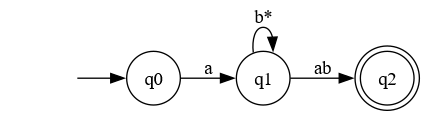

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Display of the state diagram of an example GNFA.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_1 = "1"
title_1 = "Generalized Nondeterministic Finite Automaton (GNFA) example."
alt_text_1 = (
    "A Generalized Nondeterministic Finite Automaton (GNFA) with three states: q0, q1, and q2, used in the process of deriving a regular expression. "
    "State q0 is the initial state. State q2 is the single accepting state (double circle). "
    "Transitions are labeled with regular expressions: "
    "From q0, the transition to q1 is labeled 'a'. "
    "From q1, there is a self-loop labeled 'b*' (zero or more occurrences of 'b'). "
    "From q1, the transition to the accepting state q2 is labeled 'ab'. "
    "This GNFA accepts the regular language defined by the expression a(b*)(ab)."
)

display_graph_with_caption(GNFA, fig_num_1, title_1, alt_text_1)

This GNFA would accept the string $abbbab$ by first reading $a$ and transitioning from $q0$ to $q1$, then reading $bbb$ (which is a string generated by the regular expression $b^*$) to transition from $q1$ to itself, and then finally reading $ab$ to transition from $q1$ to $q2$. Both the second and third transition arrows are not single letters, but regular expressions.

A GNFA is nondeterministic, and as a single letter is also a regular expression, the set of NFAs is contained within the set of GNFAs. Therefore, any language recognized by an NFA can be recognized by a GNFA, and we have the language containment:

Recognized by an NFA $\subseteq$ Recognized by a GNFA

We'll complete Kleene's theorem by proving that the set of languages recognized by GNFAs is contained within the set of languages generated by regular expressions.

Like we did for DFAs and NFAs we can create a GNFA class.

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# The Generalized Nondeterministic Finite Automaton (GNFA) class.
#
# Running outside Jupyter:
#   python GNFA.py
# ─────────────────────────────────────────────────────────────────────────────

class GNFA:
    """
    Represents a Generalized Nondeterministic Finite Automaton (GNFA),
    used for converting an FA to a Regular Expression.
    """
    def __init__(self, states, alphabet, transition_function, start_state, accept_states, graph_size=None):
        """
        Initializes a Generalized NFA.

        transition_function: A dictionary where (source_state, dest_state) -> Regular Expression String.
        """
        self.states = set(states)
        self.alphabet = set(alphabet)
        self.transition_function = transition_function
        self.start_state = start_state
        self.accept_states = set(accept_states)
        self.graph_size = graph_size

        self._validate()

    def _validate(self):
        """Ensures the GNFA structure is valid."""
        if self.start_state not in self.states:
            raise ValueError("Start state must be in states.")
        if not self.accept_states.issubset(self.states):
            raise ValueError("Accept states must be a subset of states.")

        for (src, dst), regex in self.transition_function.items():
            if src not in self.states or dst not in self.states:
                raise ValueError(f"Invalid transition states: {src} -> {dst}")

    def _build_graph(self):
        """Generates the graphviz Digraph object."""
        dot = Digraph()
        dot.attr(rankdir='LR')

        if self.graph_size:
            dot.attr(size=self.graph_size)

        # Start state pointer
        dot.node('', shape='none')
        dot.edge('', self.start_state)

        # Define nodes and their shapes
        for state in self.states:
            shape = 'doublecircle' if state in self.accept_states else 'circle'
            dot.node(state, label=str(state), shape=shape)

        # Draw edges labeled with the Regular Expression string
        for (src, dst), regex in self.transition_function.items():
            dot.edge(src, dst, label=str(regex))

        return dot

    def show(self, fig_num=None, title=None, alt_text="Generalized finite automaton diagram.", format='png'):
        """
        Generates and displays the GNFA digraph as an accessible HTML image
        with captioning and alt text.

        Parameters:
        - fig_num (str): Figure number (e.g., "Figure 5.1").
        - title (str): Title of the figure.
        - alt_text (str): Accessible description for screen readers (REQUIRED for compliance).
        - format (str): Output format for graphviz ('png', 'svg', etc.).
        """
        graph = self._build_graph()

        # 1. Get the raw image data using pipe()
        img_binary_data = graph.pipe(format=format)
        img_data = base64.b64encode(img_binary_data).decode('utf-8')

        # 2. Construct the caption content
        caption_content = ""
        if fig_num or title:
            caption_parts = []
            if fig_num:
                caption_parts.append(f"<b>Figure {fig_num}:</b>")
            if title:
                caption_parts.append(title)

            caption_content = " ".join(caption_parts)

        # 3. Determine the mime type for the HTML
        mime_type = f"image/{format}"

        # 4. Construct the full accessible HTML block
        html_output = f"""
        <figure style="text-align: center; margin: 1em 0;">
            <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
                 style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />

            {f'<figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">{caption_content}</figcaption>' if caption_content else ''}
        </figure>
        """
        display(HTML(html_output))

We can implement our example GNFA above as a GNFA class.


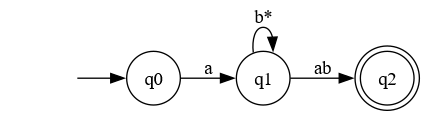

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# GNFA example implemented as a GNFA class.
# ─────────────────────────────────────────────────────────────────────────────

gnfa_example = GNFA(
    states={'q0', 'q1', 'q2'},
    alphabet={'a', 'b'},
    transition_function={
        ('q0', 'q1'): 'a',
        ('q1', 'q1'): 'b*',
        ('q1', 'q2'): 'ab'
    },
    start_state='q0',
    accept_states={'q2'}
)

fig_num_2 = "2"
title_2 = "GNFA example from GNFA class"
alt_text_2 = (
    "This is the same image as Figure 1 above"
    "A Generalized Nondeterministic Finite Automaton (GNFA) with three states: q0, q1, and q2, used in the process of deriving a regular expression. "
    "State q0 is the initial state. State q2 is the single accepting state (double circle). "
    "Transitions are labeled with regular expressions: "
    "From q0, the transition to q1 is labeled 'a'. "
    "From q1, there is a self-loop labeled 'b*' (zero or more occurrences of 'b'). "
    "From q1, the transition to the accepting state q2 is labeled 'ab'. "
    "This GNFA accepts the regular language defined by the expression a(b*)(ab)."
)

gnfa_example.show(fig_num_2, title_2, alt_text_2)

## 3. Recognized by a GNFA $\subseteq$ Generated by a Regular Expression

We'll assume we start with a GNFA. The construction consists of four steps which if followed correctly and in order will provide a regular expression that generates exactly the language recognized by the given GNFA.

### 3.1 **Step 1**: Create a unique, unenterable initial state, and a unique, unleaveable accepting state.

The basic idea here is that if there is a set of initial states, we make them no longer initial states and add a new, unique initial state with empty string transitions from the new, unique initial state to the original initial states.

Similarly, if there is a set of final states, we make them no longer final states and add a new, unique final state with empty string transitions from the original final states to the new, unique final state.

I hope you'll agree it's clear this doesn't alter the set of strings accepted by the DFA.

### 3.2 **Step 2**: When two states are joined by more than one edge going in the same direction, unify them by adding their labels.

For example, the GNFA:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Example of two edges connecting two states in a GNFA.
# ─────────────────────────────────────────────────────────────────────────────

TwoGNFA = Digraph()
TwoGNFA.attr(rankdir='LR') # This specifies the diagram should go left to right

# States
with TwoGNFA.subgraph() as l1:
  l1.attr(rank='same')
  l1.node('q1', shape='circle')
with TwoGNFA.subgraph() as l2:
  l2.attr(rank='same')
  l2.node('q2', shape='circle')

# Transitions
TwoGNFA.edge('q1', 'q2', label='r1')
TwoGNFA.edge('q1', 'q2', label='r2')


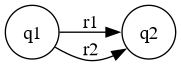

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Display of two edges connecting two states in a GNFA.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_2 = "2"
title_2 = "Two transitions to one state."
alt_text_2 = (
    "A Generalized Nondeterministic Finite Automaton (GNFA) diagram showing two states, q1 and q2. "
    "There are two parallel, distinct transitions directed from state q1 to state q2. "
    "The first transition is labeled with the regular expression 'r1', and the second transition is labeled with the regular expression 'r2'. "
    "This diagram illustrates the structure that is equivalent to the union of the two regular expressions, 'r1 + r2'."
)

display_graph_with_caption(TwoGNFA, fig_num_2, title_2, alt_text_2)

Can be reduced to:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Merging two edges connecting two states in a GNFA.
# ─────────────────────────────────────────────────────────────────────────────

OneGNFA = Digraph()
OneGNFA.attr(rankdir='LR') # This specifies the diagram should go left to right

# States
with OneGNFA.subgraph() as l1:
  l1.attr(rank='same')
  l1.node('q1', shape='circle')
with OneGNFA.subgraph() as l2:
  l2.attr(rank='same')
  l2.node('q2', shape='circle')

# Transitions
OneGNFA.edge('q1', 'q2', label='r1+r2')


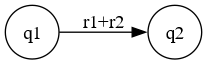

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Display of merging two edges connecting two states in a GNFA.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_3 = "3"
title_3 = "Merged transitions."
alt_text_3 = (
    "A Generalized Nondeterministic Finite Automaton (GNFA) diagram showing two states, q1 and q2, connected by a single transition. "
    "This diagram represents the simplification of two parallel paths into one equivalent path. "
    "The single transition directed from state q1 to state q2 is labeled with the regular expression 'r1+r2'. "
    "This regular expression label is the union of the two previous parallel transition labels (r1 and r2)."
)

display_graph_with_caption(OneGNFA, fig_num_3, title_3, alt_text_3)

This applies as well to loops on a single node as to transitions between two nodes. Do this step one by one, in any order, until it cannot be done anymore.

### 3.3 **Step 3**: One by one, in any order, bypass and eliminate all the non-initial and non-final states in the GNFA.

A state is bypassed by connecting each incoming edge with each outgoing edge. The label of each resultant edge is the concatenation of the label on the incoming edge with the label on the loop edge if there is one and the label on the outgoing edge.

For example, the idea here is that if you've got a GNFA like the one below, with states $q1$ through $q5$ and regular expression transition labels $r1$ through $r5$, we can just bypass this with a transition directly from state $q1$ to states $q3, q4$ and $q5$.

We start with the GNFA:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Example of GNFA that can be reduced.
# ─────────────────────────────────────────────────────────────────────────────

OGNFA = Digraph()
OGNFA.attr(rankdir='LR') # This specifies the diagram should go left to right

# States
with OGNFA.subgraph() as l1:
  l1.attr(rank='same')
  l1.node('q1', shape='circle')
with OGNFA.subgraph() as l2:
  l2.attr(rank='same')
  l2.node('q2', shape='circle')
with OGNFA.subgraph() as l3:
  l3.attr(rank='same')
  l3.node('q3', shape='circle')
  l3.node('q4', shape='circle')
  l3.node('q5', shape='circle')

# Transitions
OGNFA.edge('q1', 'q2', label='r1')
OGNFA.edge('q2', 'q2', label='r2')
OGNFA.edge('q2', 'q3', label='r3')
OGNFA.edge('q2', 'q4', label='r4')
OGNFA.edge('q2', 'q5', label='r5')


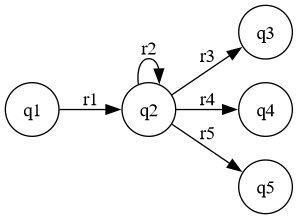

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Display of example of GNFA that can be reduced.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_4 = "4"
title_4 = "GNFA State Structure: State q2 with a Self-Loop and Multiple Outgoing Transitions"
alt_text_4 = (
    "A Generalized Nondeterministic Finite Automaton (GNFA) fragment showing five states: q1, q2, q3, q4, and q5. "
    "State q1 transitions to q2 with the regular expression 'r1'. "
    "State q2 has a self-loop transition labeled 'r2'. "
    "State q2 transitions outward to three other states: to q3 with label 'r3', to q4 with label 'r4', and to q5 with label 'r5'. "
    "This structure typically represents the process of simplifying the automaton before eliminating state q2."
)

display_graph_with_caption(OGNFA, fig_num_4, title_4, alt_text_4)

We reduce it to:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Reduction of reducible GNFA.
# ─────────────────────────────────────────────────────────────────────────────

RGNFA = Digraph()
RGNFA.attr(rankdir='LR') # This specifies the diagram should go left to right

# States
with RGNFA.subgraph() as l1:
  l1.attr(rank='same')
  l1.node('q1', shape='circle')
with RGNFA.subgraph() as l2:
  l2.attr(rank='same')
  l2.node('q3', shape='circle')
  l2.node('q4', shape='circle')
  l2.node('q5', shape='circle')

# Transitions
RGNFA.edge('q1', 'q3', label='r1r2*r3')
RGNFA.edge('q1', 'q4', label='r1r2*r4')
RGNFA.edge('q1', 'q5', label='r1r2*r5')


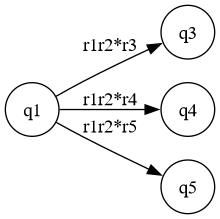

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Display of reduction of reducible GNFA.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_5 = "5"
title_5 = "GNFA State Elimination: Replacing State q2 with Equivalent Direct Transitions"
alt_text_5 = (
    "A Generalized Nondeterministic Finite Automaton (GNFA) fragment showing the result of eliminating an intermediate state. "
    "The diagram features four states: q1, q3, q4, and q5. "
    "There are three transitions originating from state q1 and leading directly to states q3, q4, and q5. "
    "The transition to q3 is labeled with the regular expression 'r1r2*r3'. "
    "The transition to q4 is labeled 'r1r2*r4'. "
    "The transition to q5 is labeled 'r1r2*r5'. "
    "This structure shows how the paths that passed through the self-loop r2 at the eliminated state have been combined into single, direct regular expressions."
)

display_graph_with_caption(RGNFA, fig_num_5, title_5, alt_text_5)

Note that the strings that would transition from, say, $q1$ to $q3$ in the first GNFA are the same as those that would transition from $q1$ to $q3$ in the second. We've just eliminated the middleman state $q2$ in the second.

### 3.4 **Step 4**: Finally, when all that is left is one edge from the unique initial state to the unique accepting state, the label on that edge is a regular expression that generates the same language as was recognized by the original GNFA.

This is it. You just apply steps 2 and 3 repeatedly until two nodes (the initial and accepting) are left, and there is a single transition from the initial to the accepting state. The regular expression for that unique edge generates the language accepted by the original GNFA.

This procedure works. However, as mentioned above, to formally prove this we'd have to construct a more precise argument for why it must work and why it always works. We won't focus on that here, but complete formal proofs can be found in the textbooks referenced at the end of the chapter.

We can implement this entire procedure as a function that accepts a GNFA object and returns a regular expression that generates the language recognized by the GNFA object.

In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# Function that transforms a GNFA object into a regular expression.
#
# Running outside Jupyter:
#   python to_regex.py
# ─────────────────────────────────────────────────────────────────────────────

def to_regex(gnfa):
    """
    Converts a GNFA object to a Regular Expression string
    using the State Elimination algorithm.
    """
    # -------------------------------------------------------------
    # STEP 1: Create unique, unenterable initial and unleaveable accept
    # -------------------------------------------------------------

    # Work on a copy of the transitions to avoid mutating the original object
    transitions = gnfa.transition_function.copy()
    states = gnfa.states.copy()

    # Define new unique names that definitely aren't in the original set
    # (We use distinct strings to avoid collision)
    real_start = "QS_START"
    real_accept = "QA_ACCEPT"

    states.add(real_start)
    states.add(real_accept)

    # Add epsilon (lambda) transition from New Start -> Old Start
    # We represent epsilon as an empty string ""
    transitions[(real_start, gnfa.start_state)] = ""

    # Add epsilon (lambda) transitions from Old Accepts -> New Accept
    for acc in gnfa.accept_states:
        transitions[(acc, real_accept)] = ""

    # -------------------------------------------------------------
    # STEP 2 & 3: Eliminate states one by one
    # -------------------------------------------------------------

    # We remove every state except the new Start and new Accept
    states_to_remove = list(gnfa.states)

    for rip_node in states_to_remove:

        # Identify incoming and outgoing paths for the node we are removing
        incoming = [s for s, d in transitions.keys() if d == rip_node]
        outgoing = [d for s, d in transitions.keys() if s == rip_node]

        # Check if the node loops to itself
        loop_regex = transitions.get((rip_node, rip_node), None)

        # Reconnect every Incoming node to every Outgoing node
        for p in incoming:
            if p == rip_node: continue # Ignore self-loops here

            for q in outgoing:
                if q == rip_node: continue # Ignore self-loops here

                # Extract the regex components
                # Path: p -> rip_node -> (loop)* -> q

                r1 = transitions[(p, rip_node)]       # Incoming

                # Loop: If exists, wrap in ( )*
                r2 = f"({loop_regex})*" if loop_regex else ""

                r3 = transitions[(rip_node, q)]       # Outgoing

                # --- Concatenation Logic ---
                # We simply join them. We use parentheses if the regex is complex
                # (length > 1) to ensure order of operations is preserved.

                parts = []
                if r1: parts.append(f"({r1})" if len(r1) > 1 else r1)
                if r2: parts.append(r2)
                if r3: parts.append(f"({r3})" if len(r3) > 1 else r3)

                new_path_regex = "".join(parts)

                # --- Union Logic ---
                # If there was ALREADY a path from p->q, we Union (+) the new path
                if (p, q) in transitions:
                    existing = transitions[(p, q)]
                    if existing:
                        transitions[(p, q)] = f"{existing}+{new_path_regex}"
                    else:
                        transitions[(p, q)] = new_path_regex
                else:
                    transitions[(p, q)] = new_path_regex

        # Delete the ripped node and all associated edges from the dictionary
        keys_to_remove = [k for k in transitions.keys() if rip_node in k]
        for k in keys_to_remove:
            del transitions[k]

        states.remove(rip_node)

    # -------------------------------------------------------------
    # STEP 4: Return the final label on the single remaining edge
    # -------------------------------------------------------------
    return transitions.get((real_start, real_accept), "")

For our example GNFA above this function produces.

In [54]:
regex_result = to_regex(gnfa_example)
print(f"Resulting Regular Expression: {regex_result}")

Resulting Regular Expression: a(b*)*((ab))


Note this is technically correct (the best type of correct!), but it's not the only regular expression that would generate the language, and $\textbf{a}\textbf{b}^{*}\textbf{ab}$ would be more compact.

Note that we could also implement this function as a method within the GNFA class, and we do that in the code at the start of the Practice Problems (Section 6.6) below.

## 4. Regular Languages

Kleene's Theorem states that, for a given alphabet $\Sigma$,  the following sets are equal:

* The set of languages that can be recognized by a DFA.
* The set of languages that can be recognized by a NFA.
* The set of languages that can be generated by a regular expression.

Call these sets $DFA$, $NFA$, and $REG$, respectively. In this chapter we also introduced the generalized nondeterministic finite automaton. Call the set of language that can be recognized by a GNFA, well, $GNFA$.

Obviously $DFA \subseteq NFA$, as DFAs are NFAs. Obviously $NFA \subseteq GNFA$, as NFAs are GNFAs. We proved in the previous chapter that $REG \subseteq DFA$. We proved in this chapter that $GNFA \subseteq REG$. So, we have the following containments:

$$DFA \subseteq NFA \subseteq GNFA \subseteq REG \subseteq DFA$$

The only way this is possible is if they're all equal. So, all these sets of languages are the same. We call this set the **regular languages**.

You may well ask whether all languages over an alphabet are regular. The answer, it turns out, is *no*, and we'll discuss this in the next chapter.

## 5. References and Further Reading

* Introduction to Computer Theory (Second Edition) by Daniel I.A. Cohen

  *Chapter 7 - Kleene's Theorem*

* Automata Theory, Languages, and Computation (Third Edition) by Hopcroft, Motwani, and Ullman

  *Section 3.2 - Finite Automata and Regular Expressions*

* Introduction to the Theory of Computation (Third Edition) by Michael Sipser
  
  *Section 1.2 - Nondeterminism,* *Section 1.3 - Regular Expressions*

## 6. Practice Problems

As in the previous three chapters there are no separate programming problems, as programming is integrated with the practice problems below.

We'll first redefine the GNFA class incorporating the regular expression finding function as a method.

In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# The Generalized Nondeterministic Finite Automaton (GNFA) class with the
# regular expression finding function as a method.
#
# Running outside Jupyter:
#   python GNFA.py
# ─────────────────────────────────────────────────────────────────────────────

class GNFA:
    """
    Represents a Generalized Nondeterministic Finite Automaton (GNFA),
    used for converting an FA to a Regular Expression via state elimination.
    """
    def __init__(self, states, alphabet, transition_function, start_state, accept_states, graph_size=None):
        """
        Initializes a Generalized NFA.

        transition_function: A dictionary where (source_state, dest_state) -> Regular Expression String.
        """
        self.states = set(states)
        self.alphabet = set(alphabet)
        self.transition_function = transition_function
        self.start_state = start_state
        self.accept_states = set(accept_states)
        self.graph_size = graph_size

        self._validate()

    def _validate(self):
        """Ensures the GNFA structure is valid."""
        if self.start_state not in self.states:
            raise ValueError("Start state must be in states.")
        if not self.accept_states.issubset(self.states):
            raise ValueError("Accept states must be a subset of states.")

        for (src, dst), regex in self.transition_function.items():
            if src not in self.states or dst not in self.states:
                raise ValueError(f"Invalid transition states: {src} -> {dst}")

    def _build_graph(self):
        """Generates the graphviz Digraph object."""
        dot = Digraph()
        dot.attr(rankdir='LR')

        if self.graph_size:
            dot.attr(size=self.graph_size)

        # Start state pointer
        dot.node('', shape='none')
        dot.edge('', self.start_state)

        # Define nodes and their shapes
        for state in self.states:
            shape = 'doublecircle' if state in self.accept_states else 'circle'
            dot.node(state, label=str(state), shape=shape)

        # Draw edges labeled with the Regular Expression string
        for (src, dst), regex in self.transition_function.items():
            dot.edge(src, dst, label=str(regex))

        return dot

    def show(self, fig_num=None, title=None, alt_text="Generalized finite automaton diagram.", format='png'):
        """
        Generates and displays the GNFA digraph as an accessible HTML image
        with captioning and alt text.
        """
        graph = self._build_graph()

        # 1. Get the raw image data using pipe()
        img_binary_data = graph.pipe(format=format)
        img_data = base64.b64encode(img_binary_data).decode('utf-8')

        # 2. Construct the caption content
        caption_content = ""
        if fig_num or title:
            caption_parts = []
            if fig_num:
                caption_parts.append(f"<b>{fig_num}:</b>")
            if title:
                caption_parts.append(title)

            caption_content = " ".join(caption_parts)

        # 3. Determine the mime type for the HTML
        mime_type = f"image/{format}"

        # 4. Construct the full accessible HTML block
        html_output = f"""
        <figure style="text-align: center; margin: 1em 0;">
            <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
                 style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />

            {f'<figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">{caption_content}</figcaption>' if caption_content else ''}
        </figure>
        """
        display(HTML(html_output))

    def to_regex(self):
        """
        Converts a GNFA object to a Regular Expression string
        using the State Elimination algorithm.
        """
        # -------------------------------------------------------------
        # STEP 1: Setup - Create unique Start/Accept states and transitions
        # -------------------------------------------------------------

        # Working on a deep copy of inputs
        transitions = self.transition_function.copy()
        states_set = self.states.copy()

        # Define new unique names
        real_start = "QS_START"
        real_accept = "QA_ACCEPT"

        # Add new states
        states_set.add(real_start)
        states_set.add(real_accept)

        # Add epsilon (lambda) transition from New Start -> Old Start
        transitions[(real_start, self.start_state)] = "" # "" represents epsilon

        # Add epsilon (lambda) transitions from Old Accepts -> New Accept
        for acc in self.accept_states:
            transitions[(acc, real_accept)] = ""

        # Initial list of states to remove (all original states)
        # We define the order by converting the set to a list
        states_to_remove = list(self.states)

        # -------------------------------------------------------------
        # STEP 2 & 3: Eliminate states one by one (Ripping)
        # -------------------------------------------------------------

        for rip_node in states_to_remove:

            # Identify transitions relative to the node being ripped
            incoming = [s for s, d in transitions.keys() if d == rip_node and s != rip_node]
            outgoing = [d for s, d in transitions.keys() if s == rip_node and d != rip_node]

            # 1. Get the regex for the self-loop (r_loop)
            loop_regex = transitions.get((rip_node, rip_node), None)
            r_loop_star = f"({loop_regex})*" if loop_regex and loop_regex != "" else ""

            # 2. Reconnect every Incoming node (p) to every Outgoing node (q)
            for p in incoming:
                for q in outgoing:

                    # p -> rip_node (r_in)
                    r_in = transitions[(p, rip_node)]

                    # rip_node -> q (r_out)
                    r_out = transitions[(rip_node, q)]

                    # Construct the new path regex: r_in r_loop* r_out

                    # Concatenation Logic (Using parentheses for structure)
                    parts = []
                    # R_in
                    parts.append(f"({r_in})" if len(r_in) > 1 and r_in != "" else r_in)

                    # R_loop*
                    if r_loop_star: parts.append(r_loop_star)

                    # R_out
                    parts.append(f"({r_out})" if len(r_out) > 1 and r_out != "" else r_out)

                    # Join the parts, filtering out empty strings from epsilon transitions
                    new_path_regex = "".join(p for p in parts if p is not None)

                    # --- Union Logic ---
                    current_path_key = (p, q)
                    if current_path_key in transitions:
                        existing = transitions[current_path_key]
                        if existing and existing != "":
                            # Union the existing path with the newly created path
                            transitions[current_path_key] = f"({existing})+({new_path_regex})"
                        else:
                            # Existing path was epsilon or empty, so just use the new one
                            transitions[current_path_key] = new_path_regex
                    else:
                        transitions[current_path_key] = new_path_regex

            # 3. Delete the ripped node and all associated edges
            keys_to_remove = [k for k in transitions.keys() if rip_node in k]
            for k in keys_to_remove:
                del transitions[k]

        # -------------------------------------------------------------
        # STEP 4: Return the final label on the single remaining edge
        # -------------------------------------------------------------
        # The final result is the single label between the new start and new accept states.
        result_regex = transitions.get((real_start, real_accept), "")

        return result_regex

### 6.1 Implementing a GNFA Instance

For the GNFA described by the diagram below, implement it as a GNFA class instance.

In [56]:
E1 = Digraph()
E1.attr(rankdir='LR') # This specifies the diagram should go left to right

# Start arrow
E1.node('', shape='none')
E1.edge('', 'q0')

# States
with E1.subgraph() as l0:
  l0.attr(rank='same')
  l0.node('q0', shape='circle')
with E1.subgraph() as l1:
  l1.attr(rank='same')
  l1.node('q1', shape='doublecircle')
  l1.node('q2', shape='doublecircle')
  l1.node('q3', shape='circle')

# Transitions
E1.edge('q0', 'q0', label='a+b')
E1.edge('q0', 'q1', label='a')
E1.edge('q0', 'q2', label='b')
E1.edge('q0', 'q3', label='ab')
E1.edge('q3', 'q0', label='ba')


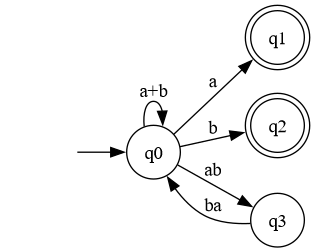

In [57]:
fig_num_6 = "6"
title_6 = "Intermediate Automaton Structure with Complex Transitions"
alt_text_6 = (
    "An automaton diagram with four states: q0, q1, q2, and q3. State q0 is the initial state. "
    "States q1 and q2 are both accepting states (double circles), while q0 and q3 are non-accepting. "
    "Transitions are defined as follows: "
    "From q0: The transition labeled 'a+b' is a self-loop back to q0. This means any 'a' or 'b' can be consumed while staying in q0. "
    "From q0: There are three outgoing transitions to q1, q2, and q3, labeled 'a', 'b', and 'ab', respectively. "
    "From q3: There is a transition back to q0 labeled 'ba'. "
    "States q1 and q2 have no outgoing transitions, making them potential terminal states."
)

display_graph_with_caption(E1, fig_num_6, title_6, alt_text_6)

In [ ]:
gnfa_E1 = GNFA(
    #YOUR CODE HERE
)

gnfa_E1.show()

### 6.2 Finding the Regular Expression Associated with a GNFA

For the GNFA from Problem 6.6.1 find the regular expression that generates the language the GNFA recognizes. Can you describe this language?

In [ ]:
#YOUR CODE HERE